# 02 - Explorative Datenanalyse: Forex-Daten (EODHD API)

**Ziel:** Forex-Kursdaten von EODHD laden, erkunden und erste Qualitaetspruefung durchfuehren.

**Währungspaare:** EUR/USD, EUR/CHF, GBP/USD

**Datenquelle:** EODHD API (https://eodhd.com)

**API-Dokumentation:** https://eodhd.com/financial-apis/api-for-historical-data-and-volumes

---

## 1. Setup und Imports

In [13]:
# Bibliotheken importieren
import requests              # HTTP-Anfragen an die API
import pandas as pd          # Datenverarbeitung
import numpy as np           # Numerische Berechnungen
import matplotlib.pyplot as plt  # Visualisierung
import seaborn as sns        # Erweiterte Visualisierung
import os                    # Dateipfade
from dotenv import load_dotenv  # API-Key aus .env laden

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. API-Key laden

Der API-Key wird aus der `.env` Datei geladen (wird nicht ins Git hochgeladen).

In [14]:
# .env Datei laden - verschiedene Pfade testen
import pathlib

for env_path in ['../.env', '.env', str(pathlib.Path.home() / 'Documents/GitHub/datawrangling/.env')]:
    if os.path.exists(env_path):
        load_dotenv(dotenv_path=env_path, override=True)
        print(f'.env gefunden unter: {env_path}')
        break

# API-Key auslesen
api_key = os.getenv('EODHD_API_KEY')

if api_key and api_key != 'dein_api_key_hier':
    print(f'API-Key geladen (beginnt mit: {api_key[:4]}...)')
else:
    print('FEHLER: Kein API-Key gefunden!')
    print(f'Aktuelles Verzeichnis: {os.getcwd()}')

.env gefunden unter: /Users/jeremynathan/Documents/GitHub/datawrangling/.env
API-Key geladen (beginnt mit: 6917...)


## 3. Daten laden von EODHD API

Die EODHD API liefert Forex-Daten im Format:

`https://eodhd.com/api/eod/EURUSD.FOREX?from=2024-01-01&to=2025-12-31&period=d&api_token=KEY&fmt=json`

Die Antwort ist ein JSON-Array mit: date, open, high, low, close, adjusted_close, volume

In [15]:
# Konfiguration: Währungspaare und Zeitraum (gleich wie Yahoo Finance!)
CURRENCY_PAIRS = {
    'EURUSD.FOREX': 'EUR/USD',
    'EURCHF.FOREX': 'EUR/CHF',
    'GBPUSD.FOREX': 'GBP/USD',
}

START_DATE = '2022-01-01'
END_DATE = '2026-03-25'

print(f'Zeitraum: {START_DATE} bis {END_DATE}')
print(f'Währungspaare: {list(CURRENCY_PAIRS.values())}')

Zeitraum: 2022-01-01 bis 2026-03-25
Währungspaare: ['EUR/USD', 'EUR/CHF', 'GBP/USD']


In [16]:
# Daten von der EODHD API laden
forex_data = {}

for eodhd_symbol, pair_name in CURRENCY_PAIRS.items():
    print(f'Lade {pair_name} ({eodhd_symbol})...')
    
    # API-URL und Parameter zusammenbauen
    url = f'https://eodhd.com/api/eod/{eodhd_symbol}'
    params = {
        'from': START_DATE,
        'to': END_DATE,
        'period': 'd',
        'api_token': api_key,
        'fmt': 'json'
    }
    
    # HTTP-GET Request ausführen
    response = requests.get(url, params=params)
    
    # Status prüfen
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        forex_data[pair_name] = df
        print(f'  -> {len(df)} Zeilen geladen')
    else:
        print(f'  -> FEHLER: HTTP {response.status_code}')

print('\nAlle Daten geladen!')

Lade EUR/USD (EURUSD.FOREX)...
  -> 1384 Zeilen geladen
Lade EUR/CHF (EURCHF.FOREX)...
  -> 1151 Zeilen geladen
Lade GBP/USD (GBPUSD.FOREX)...
  -> 1387 Zeilen geladen

Alle Daten geladen!


## 4. Erste Datenübersicht

In [17]:
# Übersicht für jedes Währungspaar
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    print(f'Shape (Zeilen x Spalten): {df.shape}')
    print(f'Zeitraum: {df.index.min()} bis {df.index.max()}')
    print(f'Spalten: {list(df.columns)}')
    print(f'Datentypen:\n{df.dtypes}')
    print(f'\nErste 3 Zeilen:')
    display(df.head(3))


EUR/USD
Shape (Zeilen x Spalten): (1384, 6)
Zeitraum: 2022-01-02 00:00:00 bis 2026-03-24 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-02,1.1373,1.1379,1.1367,1.1373,1.1373,73
2022-01-03,1.1373,1.1376,1.1280,1.1302,1.1302,841
2022-01-04,1.1302,1.1323,1.1273,1.1283,1.1283,281



EUR/CHF
Shape (Zeilen x Spalten): (1151, 6)
Zeitraum: 2022-01-03 00:00:00 bis 2026-03-25 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-03,1.0372,1.0391,1.0349,1.0372,1.0372,0
2022-01-04,1.0379,1.0383,1.0335,1.0379,1.0379,0
2022-01-05,1.0337,1.0384,1.0335,1.0337,1.0337,0



GBP/USD
Shape (Zeilen x Spalten): (1387, 6)
Zeitraum: 2022-01-02 00:00:00 bis 2026-03-24 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2022-01-02,1.3529,1.3535,1.3521,1.3522,1.3522,79
2022-01-03,1.3522,1.3530,1.3431,1.3483,1.3483,690
2022-01-04,1.3483,1.3558,1.3460,1.3530,1.3530,189


## 5. Datenqualitaetspruefung

In [18]:
# Fehlende Werte prüfen
print('FEHLENDE WERTE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    
    print(f'\n{pair_name}:')
    if missing.sum() == 0:
        print('  Keine fehlenden Werte!')
    else:
        for col in df.columns:
            if missing[col] > 0:
                print(f'  {col}: {missing[col]} fehlend ({missing_pct[col]}%)')

FEHLENDE WERTE PRO WAEHRUNGSPAAR

EUR/USD:
  Keine fehlenden Werte!

EUR/CHF:
  Keine fehlenden Werte!

GBP/USD:
  Keine fehlenden Werte!


In [19]:
# Duplikate prüfen
print('DUPLIKATE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    dupes = df.index.duplicated().sum()
    print(f'{pair_name}: {dupes} Duplikate')

DUPLIKATE PRO WAEHRUNGSPAAR
EUR/USD: 0 Duplikate
EUR/CHF: 0 Duplikate
GBP/USD: 0 Duplikate


In [20]:
# Deskriptive Statistik
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'Deskriptive Statistik: {pair_name}')
    print(f'{"=" * 50}')
    display(df.describe())


Deskriptive Statistik: EUR/USD


,open,high,low,close,adjusted_close,volume
count,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1.384000e+03
mean,1.093442,1.096930,1.090029,1.093526,1.093526,6.210097e+05
std,0.049866,0.049499,0.050246,0.049904,0.049904,3.484582e+06
min,0.959600,0.967100,0.953600,0.959600,0.959600,0.000000e+00
25%,1.062450,1.066375,1.058850,1.062500,1.062500,1.467500e+02
50%,1.087000,1.090050,1.084100,1.086900,1.086900,4.240000e+02
75%,1.132900,1.136900,1.129600,1.133025,1.133025,1.005472e+05
max,1.204000,1.208300,1.190600,1.204100,1.204100,3.648937e+07



Deskriptive Statistik: EUR/CHF


,open,high,low,close,adjusted_close,volume
count,1151.000000,1151.000000,1151.000000,1151.000000,1151.000000,1151.0
mean,0.962262,0.964621,0.959742,0.962273,0.962273,0.0
std,0.033268,0.033651,0.032855,0.033258,0.033258,0.0
min,0.897300,0.901000,0.896900,0.900200,0.900200,0.0
25%,0.935850,0.938050,0.933900,0.935800,0.935800,0.0
50%,0.956500,0.958900,0.953800,0.956500,0.956500,0.0
75%,0.981350,0.983750,0.979000,0.981350,0.981350,0.0
max,1.059800,1.061100,1.054900,1.059400,1.059400,0.0



Deskriptive Statistik: GBP/USD


,open,high,low,close,adjusted_close,volume
count,1387.000000,1387.000000,1387.000000,1387.000000,1387.000000,1.387000e+03
mean,1.276013,1.280093,1.271740,1.276022,1.276022,5.419616e+06
std,0.058036,0.057069,0.059094,0.058007,0.058007,1.024524e+07
min,1.072600,1.083800,1.034400,1.072600,1.072600,0.000000e+00
25%,1.240350,1.244650,1.236450,1.240150,1.240150,1.850000e+02
50%,1.271800,1.275200,1.268600,1.271800,1.271800,5.420000e+02
75%,1.328800,1.332550,1.325350,1.328800,1.328800,1.668341e+06
max,1.382700,1.386800,1.375000,1.382700,1.382700,4.198349e+07


## 6. Visualisierung

### 6.1 Kursverlauf (Close-Preis)

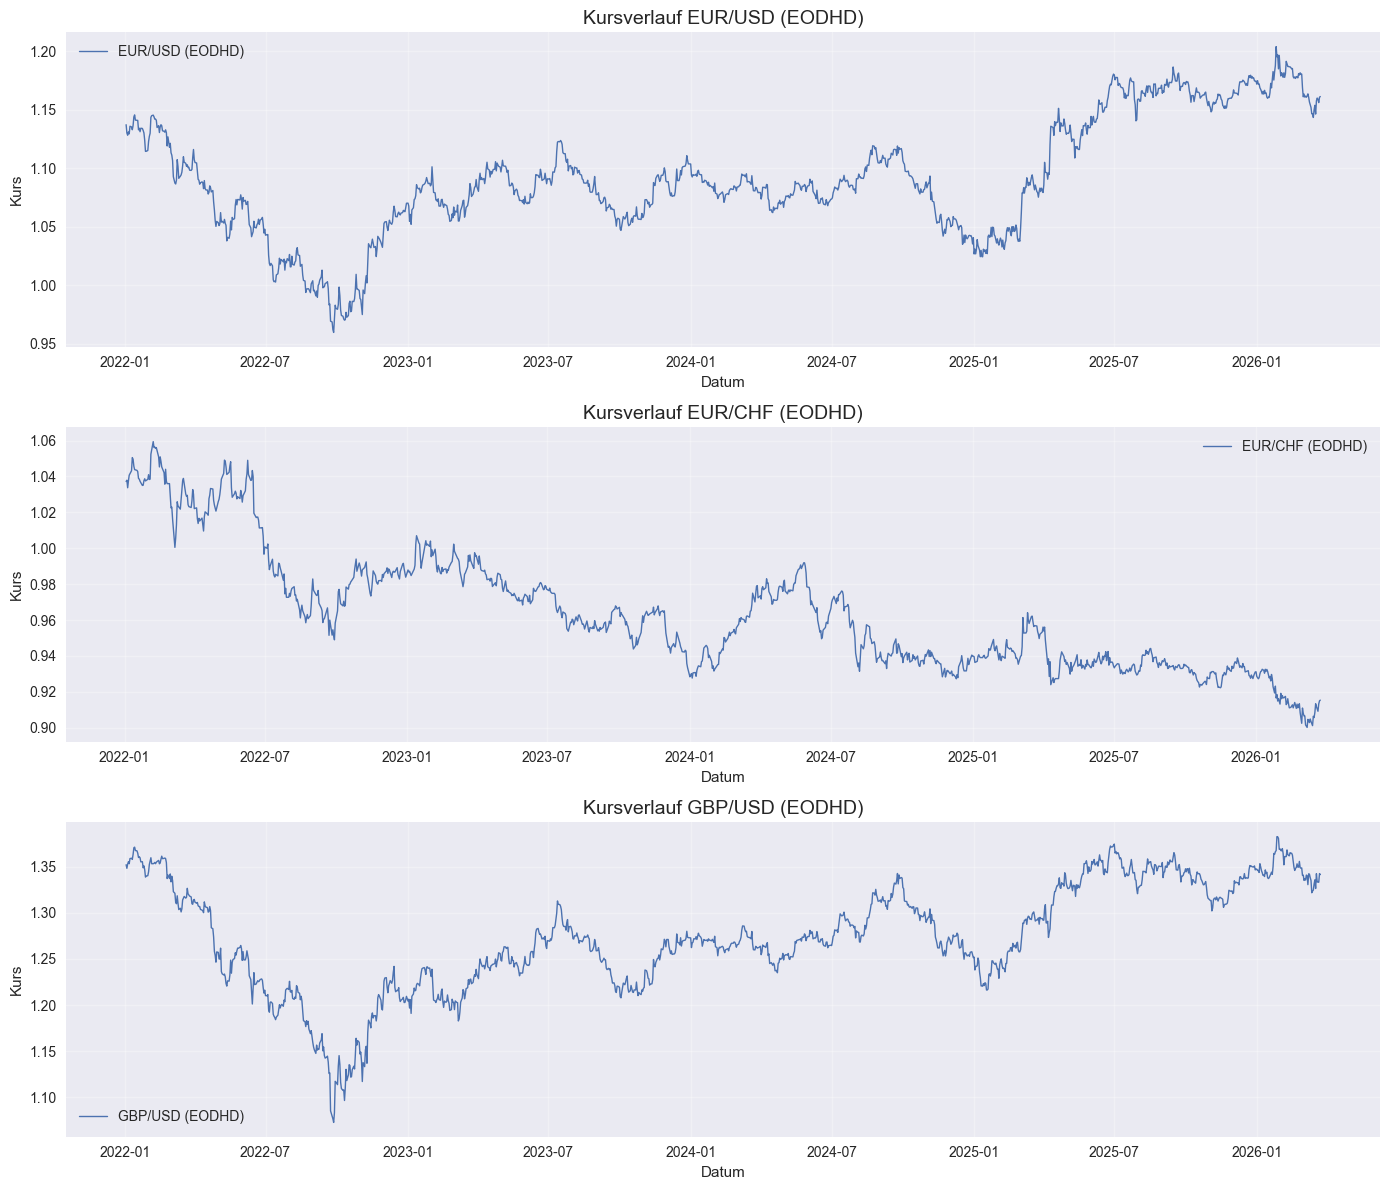

In [21]:
# Kursverlauf plotten
fig, axes = plt.subplots(len(forex_data), 1, figsize=(14, 4 * len(forex_data)))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    ax.plot(df.index, df['close'], label=f'{pair_name} (EODHD)', linewidth=1)
    ax.set_title(f'Kursverlauf {pair_name} (EODHD)', fontsize=14)
    ax.set_xlabel('Datum')
    ax.set_ylabel('Kurs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Verteilung der täglichen Renditen

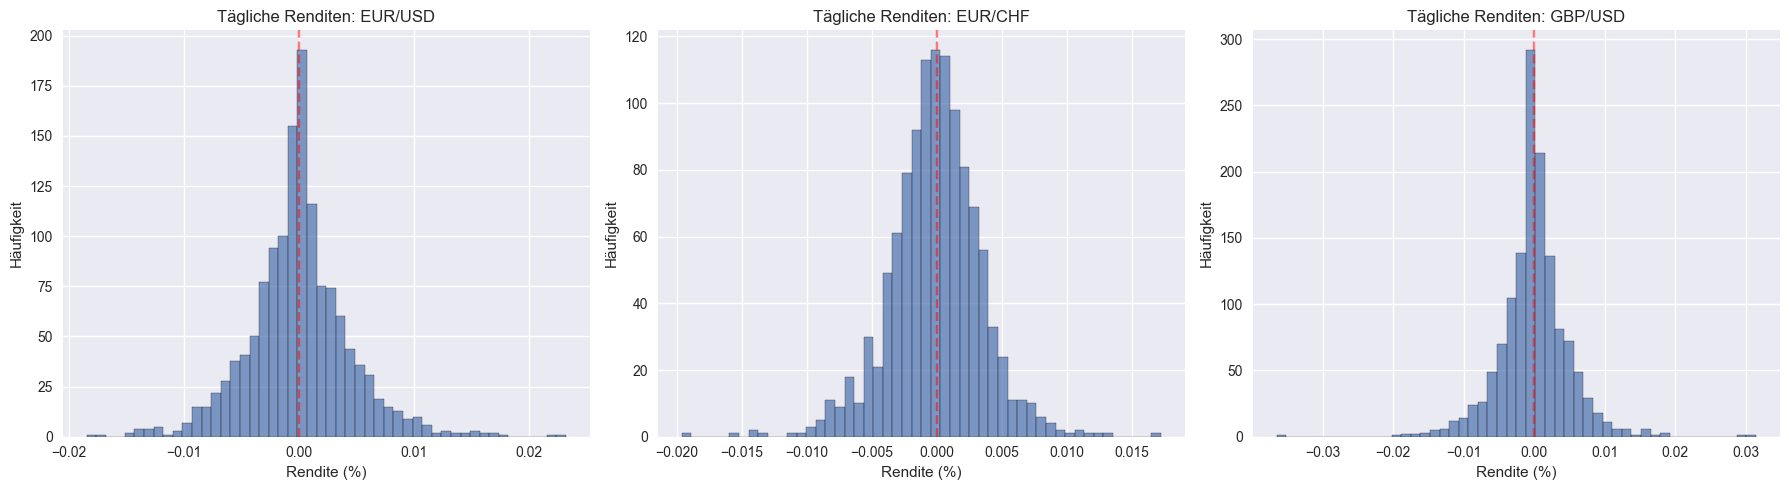

In [22]:
# Tägliche Renditen
fig, axes = plt.subplots(1, len(forex_data), figsize=(6 * len(forex_data), 5))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    returns = df['close'].pct_change().dropna()
    ax.hist(returns, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Tägliche Renditen: {pair_name}', fontsize=12)
    ax.set_xlabel('Rendite (%)')
    ax.set_ylabel('Häufigkeit')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6.3 Fehlende Tage identifizieren

In [23]:
# Alle fehlenden Tage anzeigen
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    
    all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    missing_days = all_days.difference(df.index)
    missing_weekends = [d for d in missing_days if d.weekday() >= 5]
    missing_weekdays = [d for d in missing_days if d.weekday() < 5]
    
    print(f'Gesamte fehlende Tage:     {len(missing_days)}')
    print(f'  davon Wochenenden:       {len(missing_weekends)}')
    print(f'  davon Wochentage:        {len(missing_weekdays)}')
    
    if len(missing_weekdays) > 0:
        print(f'\n  Fehlende Wochentage (Feiertage etc.):')
        for d in missing_weekdays:
            day_name = ['Mo', 'Di', 'Mi', 'Do', 'Fr'][d.weekday()]
            print(f'    {d.strftime("%Y-%m-%d")} ({day_name})')


EUR/USD
Gesamte fehlende Tage:     159
  davon Wochenenden:       159
  davon Wochentage:        0

EUR/CHF
Gesamte fehlende Tage:     392
  davon Wochenenden:       392
  davon Wochentage:        0

GBP/USD
Gesamte fehlende Tage:     156
  davon Wochenenden:       156
  davon Wochentage:        0


## 7. Rohdaten speichern

In [24]:
# Rohdaten als CSV speichern
OUTPUT_DIR = '../../data/raw/forex/eodhd'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for pair_name, df in forex_data.items():
    safe_name = pair_name.replace('/', '_')
    filename = f'{safe_name}_{START_DATE}_to_{END_DATE}.csv'
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath)
    print(f'Gespeichert: {filepath} ({len(df)} Zeilen)')

print('\nAlle Rohdaten gespeichert!')

Gespeichert: ../../data/raw/forex/eodhd/EUR_USD_2022-01-01_to_2026-03-25.csv (1384 Zeilen)
Gespeichert: ../../data/raw/forex/eodhd/EUR_CHF_2022-01-01_to_2026-03-25.csv (1151 Zeilen)
Gespeichert: ../../data/raw/forex/eodhd/GBP_USD_2022-01-01_to_2026-03-25.csv (1387 Zeilen)

Alle Rohdaten gespeichert!


## 8. Zusammenfassung

### Erkenntnisse aus der EDA:
- **Datenumfang:** (hier Ergebnisse eintragen nach Ausfuehrung)
- **Fehlende Werte:** (hier Ergebnisse eintragen)
- **Duplikate:** (hier Ergebnisse eintragen)
- **Auffaelligkeiten:** (hier Ergebnisse eintragen)

### Nächste Schritte:
1. Datenqualitaet zwischen Yahoo und EODHD vergleichen
2. Daten bereinigen und harmonisieren
3. Nachrichten laden (EODHD News API + Webscraping)